In [1]:
import numpy as np

DIR = "/home/ubuntu/yfcc-scope/embeddings/dinov3"
centroids = np.load(f"{DIR}/faiss_kmeans_centroids.npy")
assignments = np.load(f"{DIR}/faiss_kmeans_assignments.npy")

In [2]:
assignments.shape, centroids.shape

((9995825,), (10000, 384))

In [3]:
centroids[:10]

array([[ 0.00042467, -0.02863051,  0.00703919, ...,  0.01460796,
         0.01721136, -0.00458771],
       [-0.01686179, -0.0276235 ,  0.02985463, ..., -0.00677705,
         0.01682497,  0.03736084],
       [ 0.00439149,  0.01228143,  0.05538256, ...,  0.05405507,
        -0.03711288,  0.06047312],
       ...,
       [-0.0426169 , -0.03865698,  0.01660646, ...,  0.0301404 ,
         0.00621866,  0.07981909],
       [ 0.00340544,  0.04958165, -0.00258855, ...,  0.03403784,
        -0.02427439, -0.02466498],
       [ 0.00878859,  0.00269075,  0.00460524, ..., -0.01001982,
         0.01438212,  0.05308436]], shape=(10, 384), dtype=float32)

In [4]:
k = centroids.shape[0]
n = assignments.shape[0]
counts = np.bincount(assignments, minlength=k)

### Cluster Size Distribution

In [5]:
print(f"n_vectors = {n}, k = {k}")
print(f"mean size = {counts.mean():.1f}, median size = {np.median(counts):.1f}")
print(f"std = {counts.std():.1f}, min = {counts.min()}, max = {counts.max()}")

for p in [0, 1, 5, 25, 50, 75, 95, 99, 100]:
    print(f"p{p:>3}: {np.percentile(counts, p):.0f}")

n_vectors = 9995825, k = 10000
mean size = 999.6, median size = 975.0
std = 293.4, min = 92, max = 3538
p  0: 92
p  1: 378
p  5: 569
p 25: 813
p 50: 975
p 75: 1154
p 95: 1525
p 99: 1874
p100: 3538


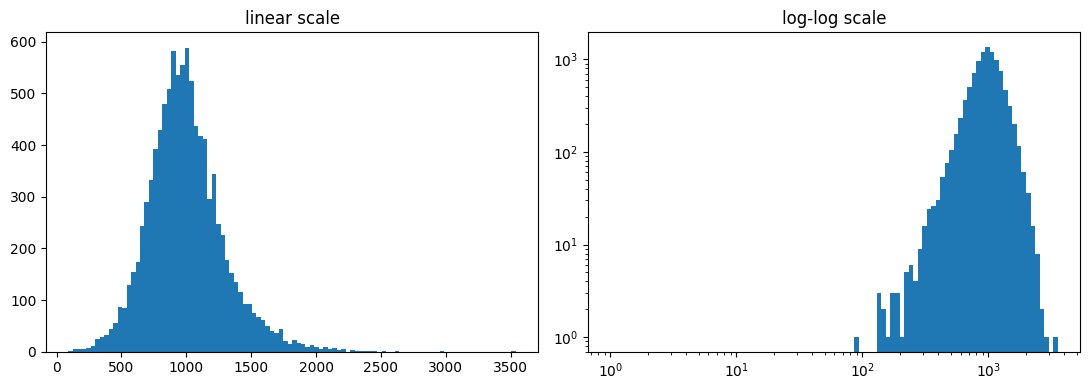

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(counts, bins=100)
axes[0].set_title("linear scale")

axes[1].hist(counts, bins=np.logspace(0, np.log10(counts.max()+1), 100))
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("log-log scale")
plt.tight_layout()
plt.show()

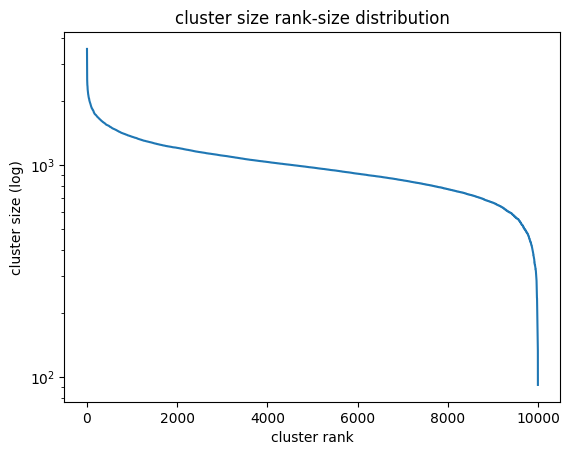

In [7]:
sorted_counts = np.sort(counts)[::-1]
plt.plot(sorted_counts)
plt.yscale("log")
plt.xlabel("cluster rank")
plt.ylabel("cluster size (log)")
plt.title("cluster size rank-size distribution")
plt.show()

### PCA

In [15]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

df = pd.DataFrame(centroids)
scaler = StandardScaler()
scaled_centroids = scaler.fit_transform(df)

pca = PCA()
reduced_centroids = pca.fit_transform(scaled_centroids)

In [16]:
reduced_centroids

array([[ 7.81232044e-02,  2.34618711e+00, -1.14094174e+00, ...,
         6.46838471e-02, -9.46679860e-02, -1.10830297e-04],
       [ 5.34175968e+00, -1.03085394e+01,  3.02794695e+00, ...,
        -7.68553391e-02, -2.15971973e-02,  9.06632049e-05],
       [ 1.53542995e+00,  1.31935728e+00, -4.87954855e-01, ...,
         6.15008995e-02,  8.28835890e-02,  1.28493384e-05],
       ...,
       [ 1.68967211e+00, -1.14768565e-01,  8.85871220e+00, ...,
         2.57348432e-03, -2.44627949e-02, -3.06322509e-05],
       [ 6.09852850e-01,  3.93211633e-01, -3.22457123e+00, ...,
        -2.65396833e-01, -8.59950259e-02,  1.54946814e-04],
       [-2.90391654e-01,  4.18462372e+00, -7.98021376e-01, ...,
         1.07555740e-01,  1.67264402e-01, -2.07628240e-04]],
      shape=(10000, 384), dtype=float32)

In [17]:
df_pca = pd.DataFrame(reduced_centroids[:, :3], columns=["PC1", "PC2", "PC3"])

In [18]:
print("--- Explained Variance Ratio ---")
# Tells you what percentage of information each component contains
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"Principal Component {i+1}: {ratio:.2%}")

total_variance = sum(pca.explained_variance_ratio_)
print(f"Total information retained: {total_variance:.2%}")

--- Explained Variance Ratio ---
Principal Component 1: 8.52%
Principal Component 2: 4.05%
Principal Component 3: 2.65%
Principal Component 4: 2.27%
Principal Component 5: 1.91%
Principal Component 6: 1.75%
Principal Component 7: 1.51%
Principal Component 8: 1.44%
Principal Component 9: 1.33%
Principal Component 10: 1.28%
Principal Component 11: 1.19%
Principal Component 12: 1.09%
Principal Component 13: 1.08%
Principal Component 14: 1.08%
Principal Component 15: 1.03%
Principal Component 16: 0.98%
Principal Component 17: 0.98%
Principal Component 18: 0.93%
Principal Component 19: 0.85%
Principal Component 20: 0.83%
Principal Component 21: 0.81%
Principal Component 22: 0.79%
Principal Component 23: 0.75%
Principal Component 24: 0.74%
Principal Component 25: 0.72%
Principal Component 26: 0.71%
Principal Component 27: 0.69%
Principal Component 28: 0.68%
Principal Component 29: 0.67%
Principal Component 30: 0.65%
Principal Component 31: 0.63%
Principal Component 32: 0.62%
Principal Compon

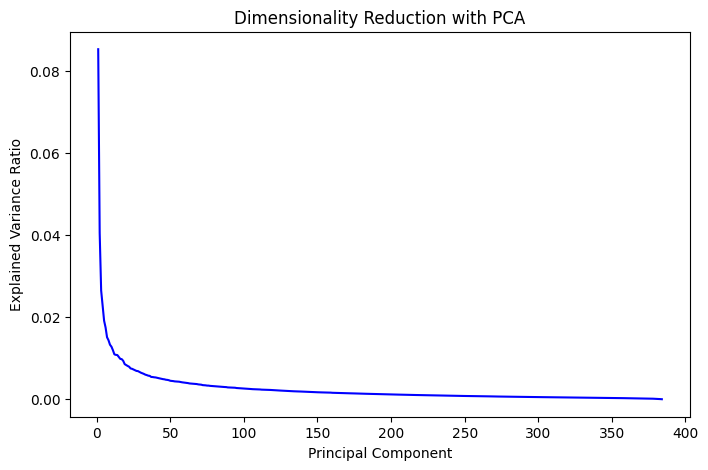

In [19]:
# Plot explained variance ratio
plt.figure(figsize=(8, 5))
x = range(1, len(pca.explained_variance_ratio_) + 1)
plt.plot(x, pca.explained_variance_ratio_, color='b')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Dimensionality Reduction with PCA')
plt.show()

In [20]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Scatter3d(
	x=df_pca["PC1"],
	y=df_pca["PC2"],
	z=df_pca["PC3"],
	mode='markers',
	marker=dict(
		size=5,
		color=np.log10(counts + 1),  # Use log scale for color
		colorscale='Viridis',
		opacity=0.8,
		colorbar=dict(title='Cluster Size (log scale)')
	)
)])

fig.update_layout(
	title='3D PCA of Cluster Centroids',
	scene=dict(
		xaxis_title='PC1',
		yaxis_title='PC2',
		zaxis_title='PC3'
	)
)
fig.show()